In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
print("Shape of dataset:", df.shape)

Shape of dataset: (119390, 32)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
print(df["is_canceled"].value_counts())

is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [7]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_876\1328342753.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [8]:
y = df["is_canceled"]

X = df.drop(
    columns=["is_canceled", "reservation_status", "reservation_status_date"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119390, 29)
y shape: (119390,)


TASK 2

In [ ]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [ ]:
#Identify columns with very high missingness. Drop them only if justified and state the reason.

high_missing = missing_table[
    missing_table["Missing Percentage"] > 50
]

high_missing

,Missing Count,Missing Percentage
company,112593,94.306893


In [11]:
print("High missingness columns:")
print(high_missing)

High missingness columns:
         Missing Count  Missing Percentage
company         112593           94.306893


removing the 'company' column as it has an extremely high percentage of missing values, which means that most rows do not contain useful information in this column.

In [12]:
df = df.drop(columns=["company"])

In [13]:
#Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.
df = df.drop(
    columns=["reservation_status", "reservation_status_date"],
    errors="ignore"
)

print("Leakage columns removed.")

Leakage columns removed.


In [15]:
#Check selected numerical features for outliers using boxplots and/or the IQR method.
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [16]:
selected_numeric = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

selected_numeric = [
    col for col in selected_numeric if col in df.columns
]

print(selected_numeric)

['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


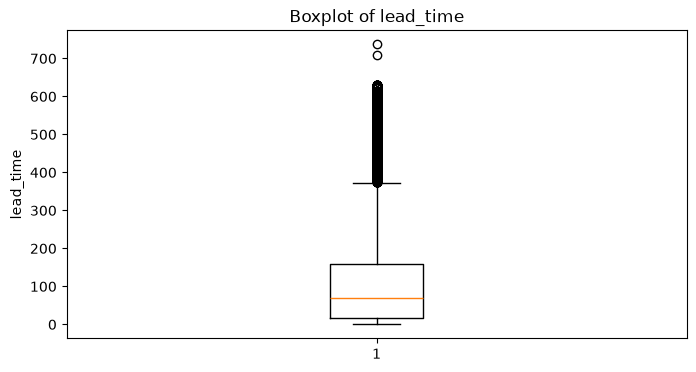

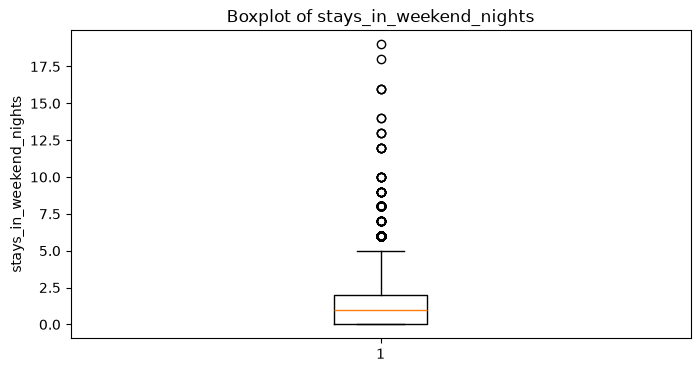

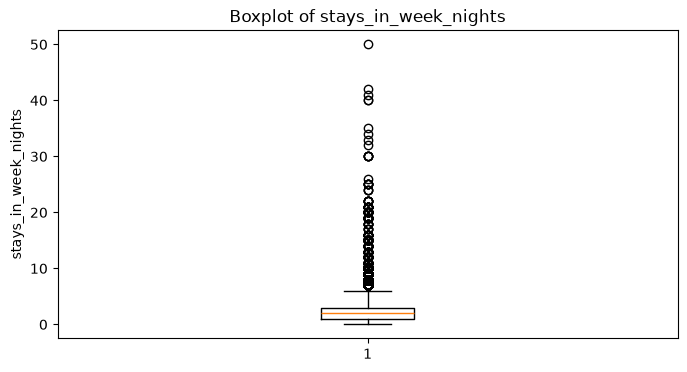

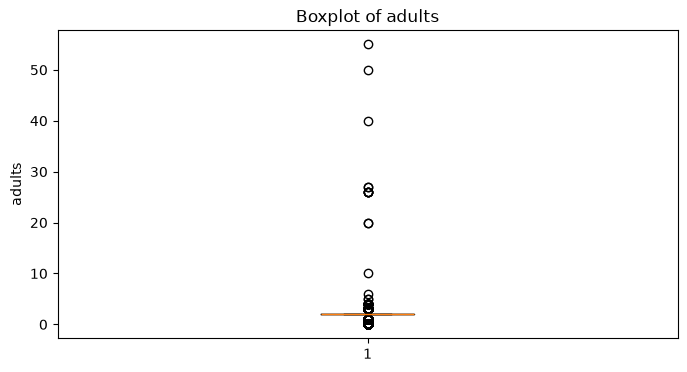

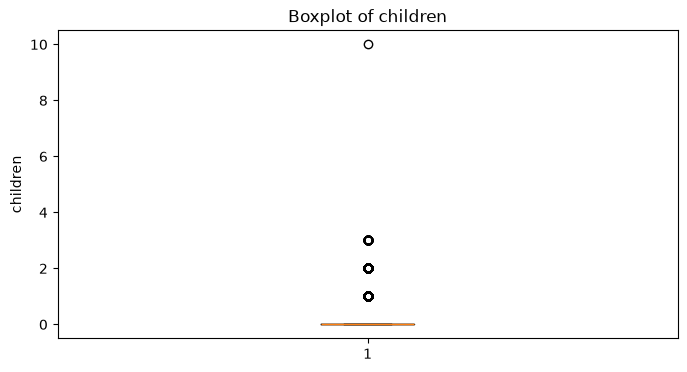

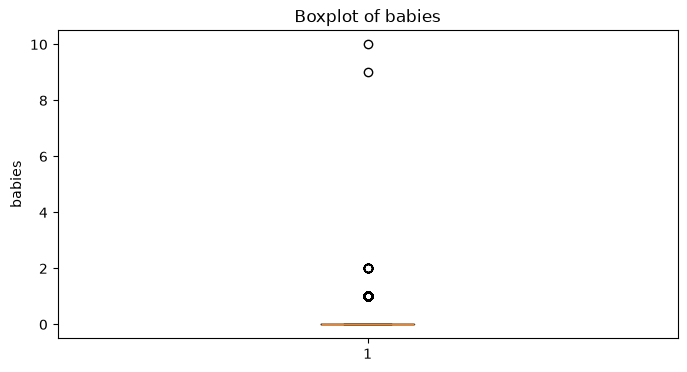

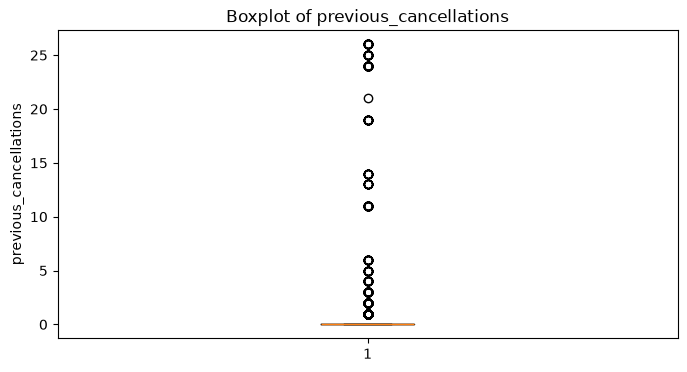

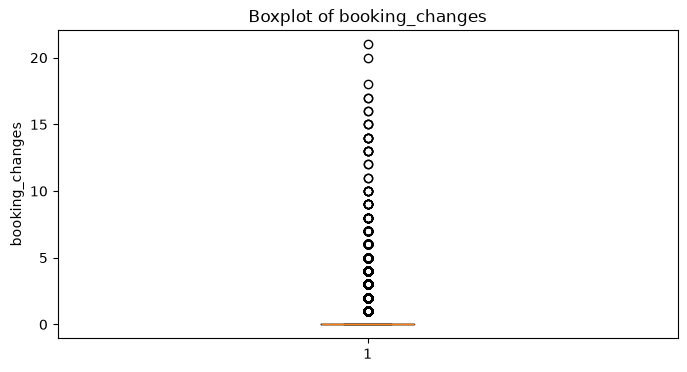

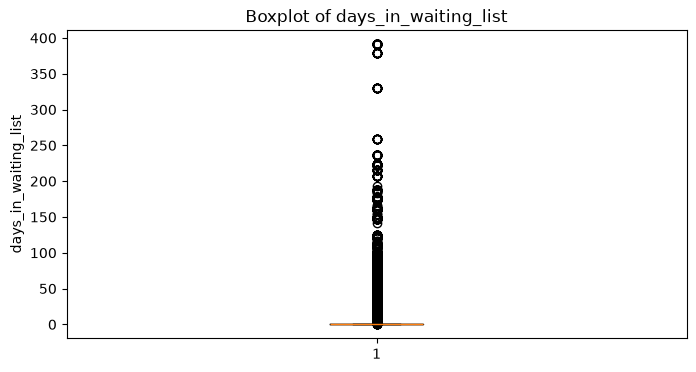

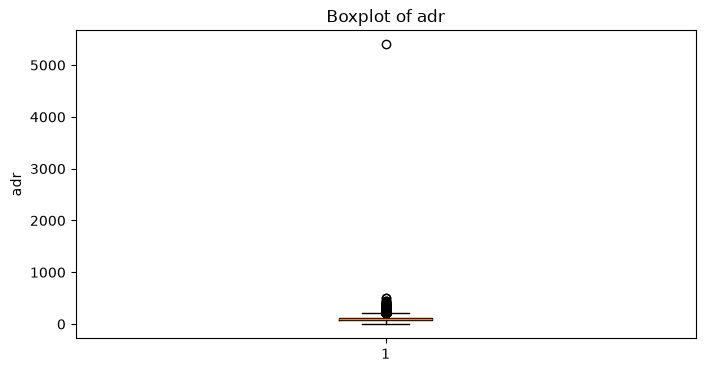

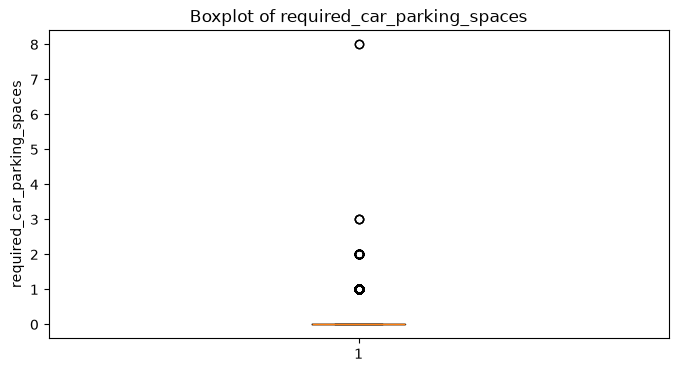

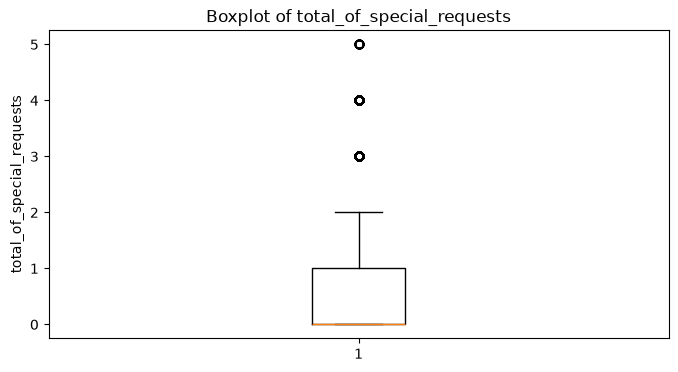

In [17]:
#boxplot
import matplotlib.pyplot as plt

for col in selected_numeric:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [18]:
outlier_summary = []

for col in selected_numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    outlier_summary.append([
        col,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outliers
    ])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=[
        "Column",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

outlier_table

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005
1,stays_in_weekend_nights,0.00,2.0,2.00,-3.000,5.000,265
2,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354
3,adults,2.00,2.0,0.00,2.000,2.000,29710
4,children,0.00,0.0,0.00,0.000,0.000,8590
5,babies,0.00,0.0,0.00,0.000,0.000,917
6,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484
7,booking_changes,0.00,0.0,0.00,0.000,0.000,18076
8,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698
9,adr,69.29,126.0,56.71,-15.775,211.065,3793


In [19]:
#Remove only clear/extreme outliers and report how many rows were removed.
before_rows = len(df)

if "adr" in df.columns:
    df = df[df["adr"] >= 0]
    
    Q1 = df["adr"].quantile(0.25)
    Q3 = df["adr"].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[df["adr"] <= upper_bound]

after_rows = len(df)

print("Rows before outlier removal:", before_rows)
print("Rows after outlier removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before outlier removal: 119390
Rows after outlier removal: 115596
Rows removed: 3794


the rows before outlier removal were 119390 and after removal were 115596, so total removed were 3794.

TASK 3 - Create Two Preprocessing Pipelines

In [20]:
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (115596, 28)
y shape: (115596,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (92476, 28)
Testing data shape: (23120, 28)


In [22]:
# Identifying numerical and categorical columns

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_876\1121585942.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [23]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [24]:
#For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

numerical_preprocessing_standard = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

numerical_preprocessing_minmax = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


#For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
# Pipeline A

preprocessor_A = ColumnTransformer([
    ("num", numerical_preprocessing_standard, numerical_columns),
    ("cat", categorical_preprocessing, categorical_columns)
])

In [26]:
# Pipeline B

preprocessor_B = ColumnTransformer([
    ("num", numerical_preprocessing_minmax, numerical_columns),
    ("cat", categorical_preprocessing, categorical_columns)
])